# Garmin Race Prediction Analysis

### Introduction
Newer Garmin hardware has been equipped with a race prediction feature which computes race predictions for different distances (5k, 10k, Half Marathon, and Marathon). I have often found myself surprised by how often these predictions accurately represent my current fitness, and how some other times they seem to be far off.\
After having cleaned and engineered numerous datasets, I will proceed by doing a more in depth analysis of my Garmin's race prediction feature. I will sepcifically aim to answer the following questions:
- How did Garmin's race predictions evolve as my training became more consistent and marathon-focused?
- When did Garmin race predictions become more stable?
- Did marathon predictions overshoot actual fitness?

In addition I will be exploring other related trends in Garmin race prediction against observed performance.

### Data & Methodology
This notebook will make use of previously cleaned and engineered datasets derived from my personal Garmin Connect export files. Specifically, I will be working with Garmin race predictions for the 5K, 10K, Half Marathon and Marathon, focusing on the latter since it is my main event. For more details on these datasets, the cleaning performed and additional engineering refer to notebooks 01-07. During the development of this analysis, I manually created an events table to track key training block starts and race dates. This contextual layer allows Garmin prediction trends to be evaluated against real training and racing milestones.

### Imports

In [1]:
# Necessary imports for exploration
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tabulate import tabulate

### Helper Functions

In [2]:
########################
### Helper functions ###
########################

# Data saving helper functions
def to_parquet(df, path):
    """Save a DataFrame to a Parquet file."""
    df.to_parquet(path, index=False)

# Plotting helper functions
def plot_line(df, x_col, y_col, title=None):
    """Plot a line graph of two columns from a DataFrame."""
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
def plot_line_with_events(events_table, df, prediction, title=None):
    """Plot a line graph with vertical lines for events."""

    # Select races
    race_events = events_table[
        events_table["event_type"] == "race"
    ]

    # Select training block starts ()
    block_events = events_table[
        events_table["event_type"] == "training_block_start"
        ]

    plt.figure(figsize=(12, 6))

    # Prediction curve
    sns.lineplot(
        data=df,
        x='date',
        y=prediction,
        linewidth=2
    )

    # Race markers
    for _, row in race_events.iterrows():
        plt.axvline(
            row["date"],
            color='red',
            linestyle='--',
            alpha=0.6
        )

        plt.text(
            row["date"],
            df[prediction].max(),
            row["label"],
            rotation=90,
            fontsize=8,
            verticalalignment='top'
        )

    # Training block starts
    for _, row in block_events.iterrows():
        plt.axvline(
            row["date"],
            color='green',
            linestyle=':',
            alpha=0.5
        )

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Data frame helper functions
def merge_dataframes_asof(left_df, right_df, left_on, right_on, direction='backward'):
    """Merge two DataFrames using an asof merge."""
    return pd.merge_asof(
        left_df.sort_values(left_on),
        right_df.sort_values(right_on),
        left_on=left_on,
        right_on=right_on,
        direction=direction
    )

# Getter function for relevant prediction
def get_relevant_prediction(row):
    """Get the relevant prediction based on the race type."""
    prediction_map = {
        "5k": "5K_pred",
        "10k": "10K_pred",
        "half": "Half_pred",
        "marathon": "Marathon_pred"
    }
    pred_col = prediction_map.get(row["race_type"])
    if pred_col:
        return row[pred_col]
    return None

### Garmin Race Predictions Over Time

I begin by observing how the Garmin race predictions have evolved since this data began to be collected. Furthermore, I compare the evolution of these predictions with specific training block dates and racing dates with the goal of observing any patterns or specific behavior.

The following visualizations show how Garmin’s race predictions evolved over time across multiple race distances. These predictions are generated internally by Garmin using physiological and training-derived metrics such as VO2 max estimation, training load, and recent performance patterns.

The purpose of this section is to establish a high-level view of how predicted race fitness evolved throughout different phases of training and racing.

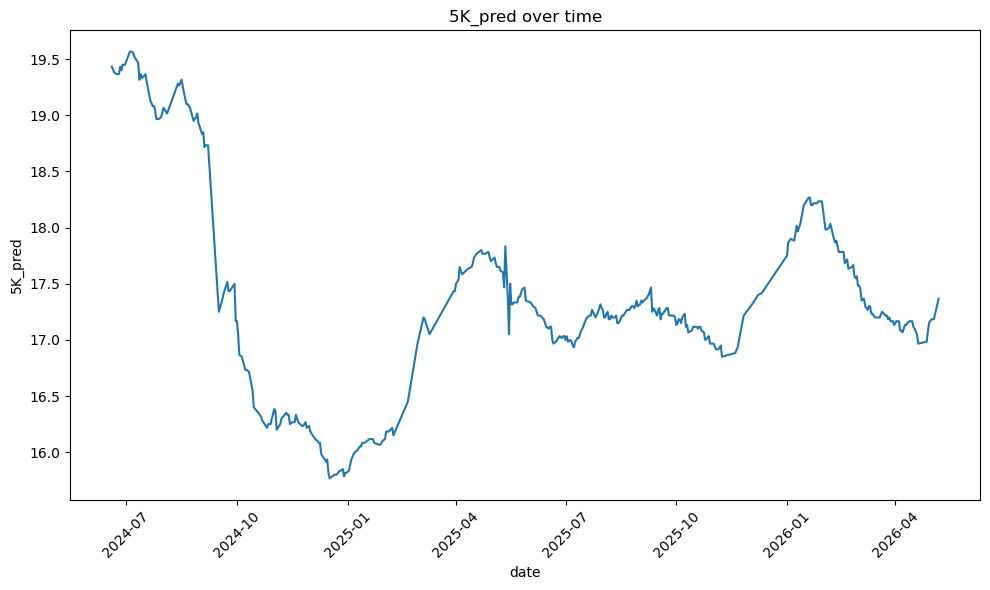

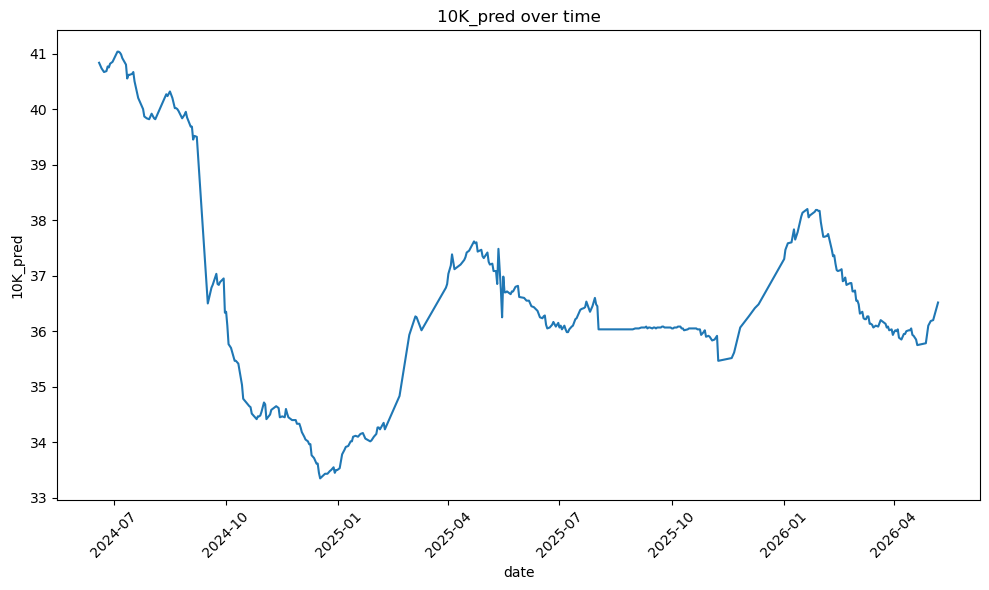

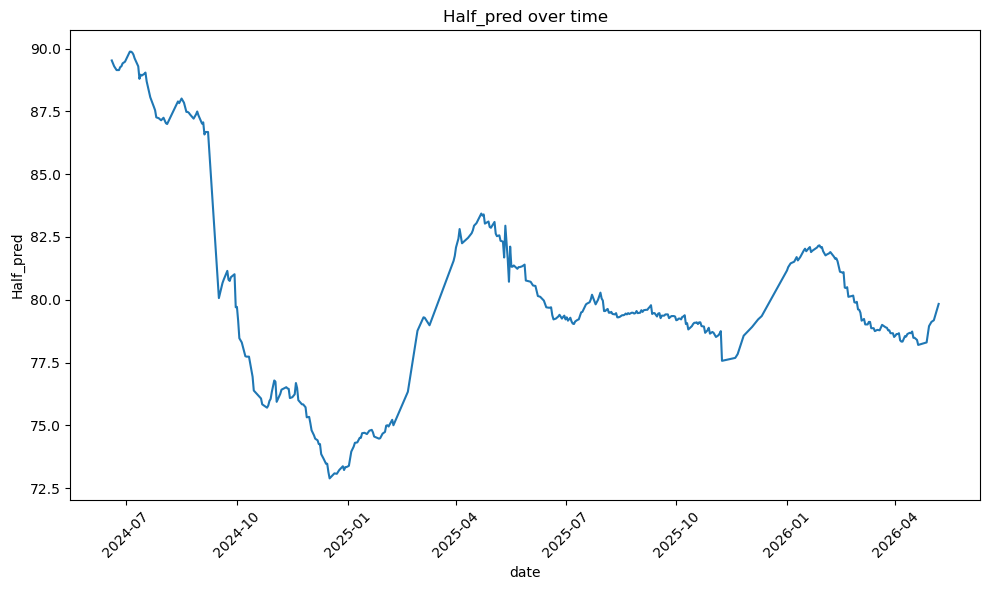

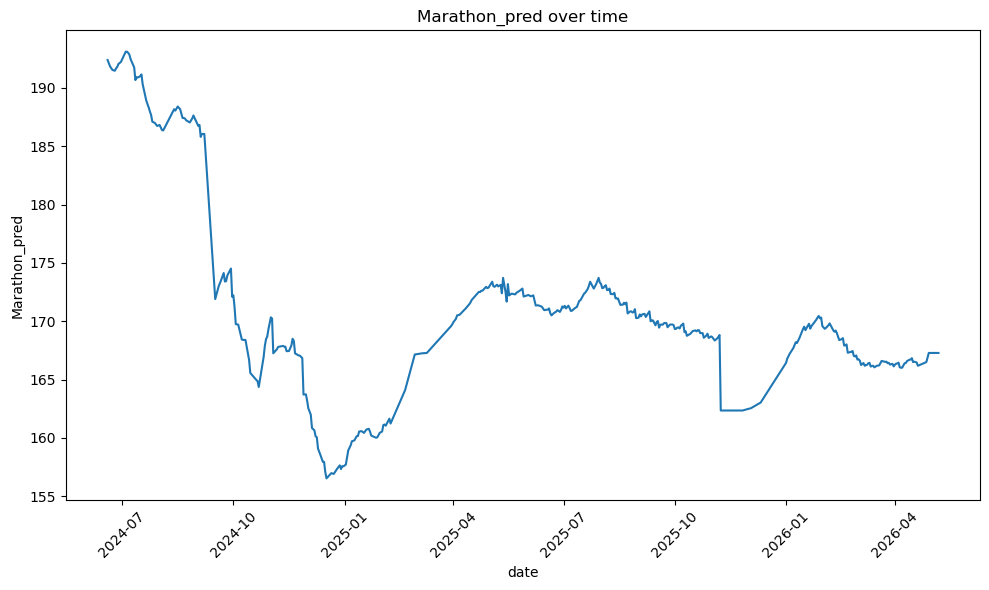

In [3]:
# Looad parquet file into a pandas DataFrame
daily_master_table = pd.read_parquet('/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/daily_master_v1.parquet')

# Replace a bug value of 511 in the 'hrv_weekly_avg_last' column with NaN
daily_master_table["hrv_weekly_avg_clean"] = (
    daily_master_table["hrv_weekly_avg_last"]
    .replace(511, np.nan)
)

# Converting prediction times to seconds in order to be used in analysis
predictions_type = ['5K_pred', '10K_pred', 'Half_pred', 'Marathon_pred']

for prediction in predictions_type:
    daily_master_table[prediction] = pd.to_timedelta(daily_master_table[prediction]) # minutes
    daily_master_table[prediction] = (
    pd.to_timedelta(daily_master_table[prediction])
    .dt.total_seconds() / 60
)
    
# Plot garmin race predictions over time
for prediction in predictions_type: 
    plot_line(daily_master_table, 'date', prediction, title=f'{prediction} over time')

Above we observe plots of Garmin prediction times over time for the four main events. I observe a very fast decline in predicted time during 2024, followed by an aggresive increse from January 2025 to around May 2025. After this it appears as though predicted time stabilizes, resulting in a very interesting pattern of humps. These humps may represent different cycles in my training (off-cycles, training, peaks etc,.). Interestingly these hump structures appear to line up between all four distances, appearing to be more aggresive for 5k and 10k predictions. I am captivated by the intial aggresive dip in prediction time. 

### Overlaying Race Events

To contextualize Garmin’s predictions, major races and training blocks were manually annotated and overlaid onto the prediction timelines. This allows predicted performance trends to be compared against actual race outcomes and important training milestones.


/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_12664/3144137063.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  events_table['date'] = pd.to_datetime(events_table['date'])


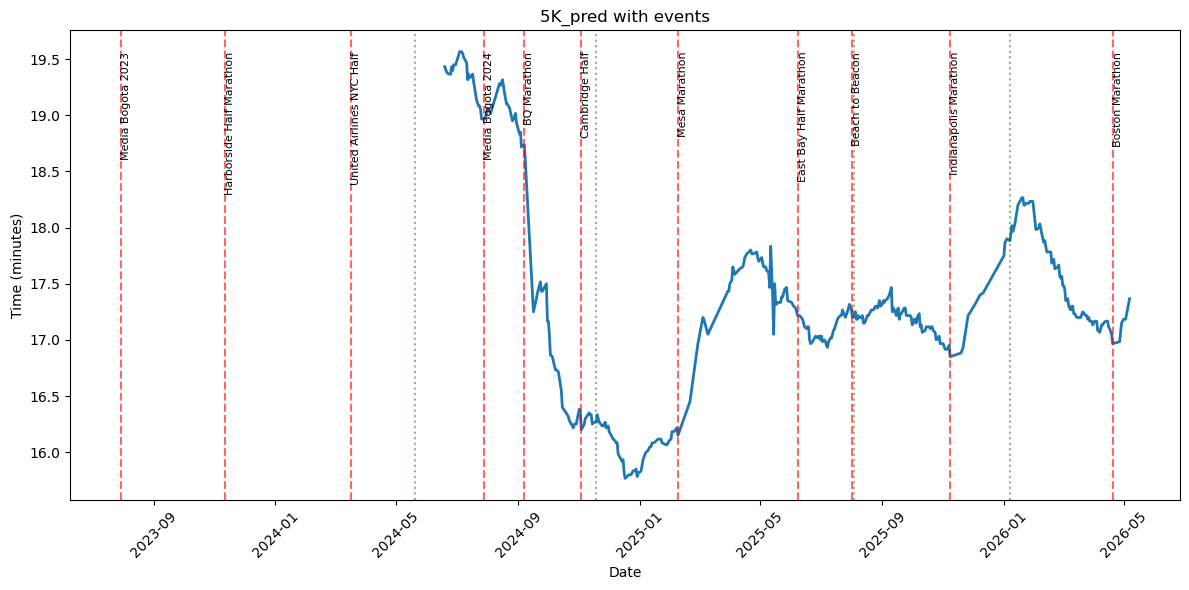

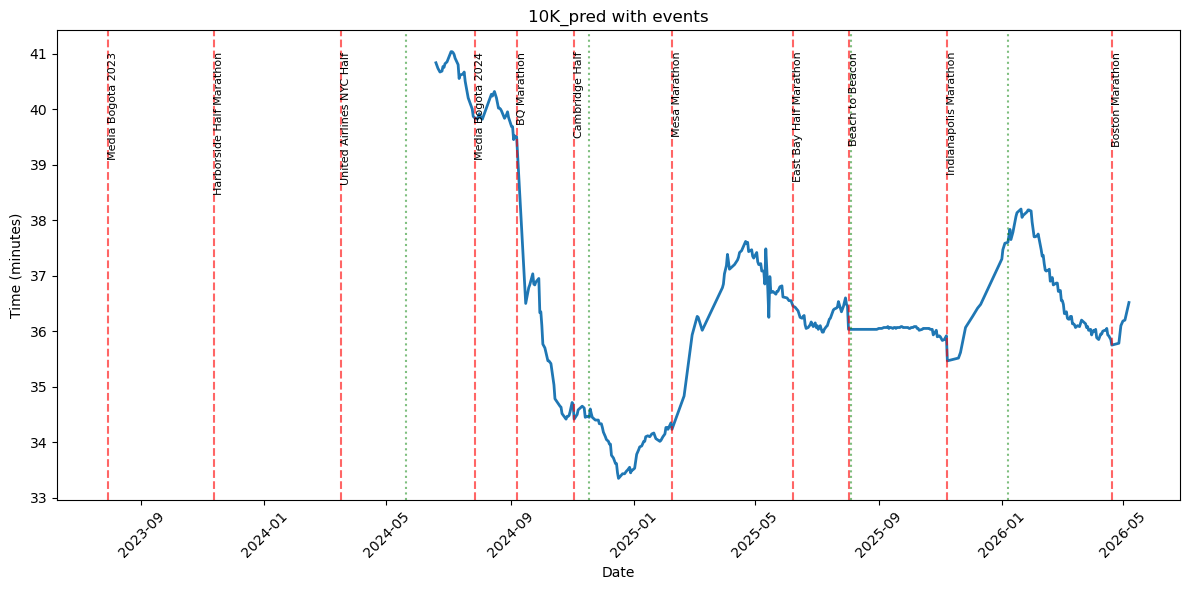

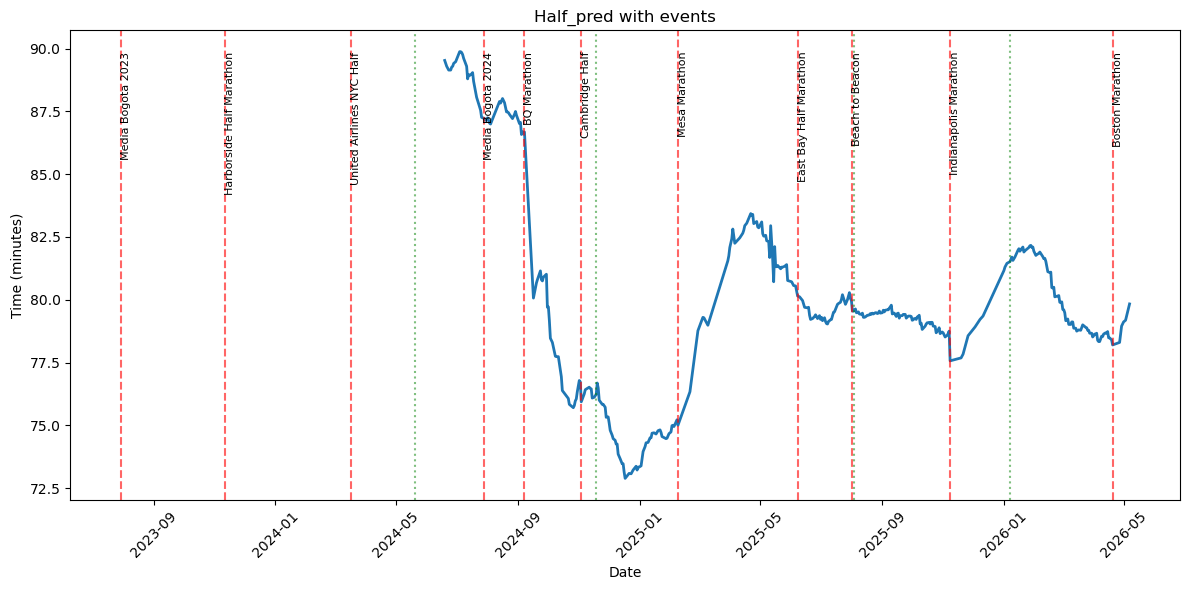

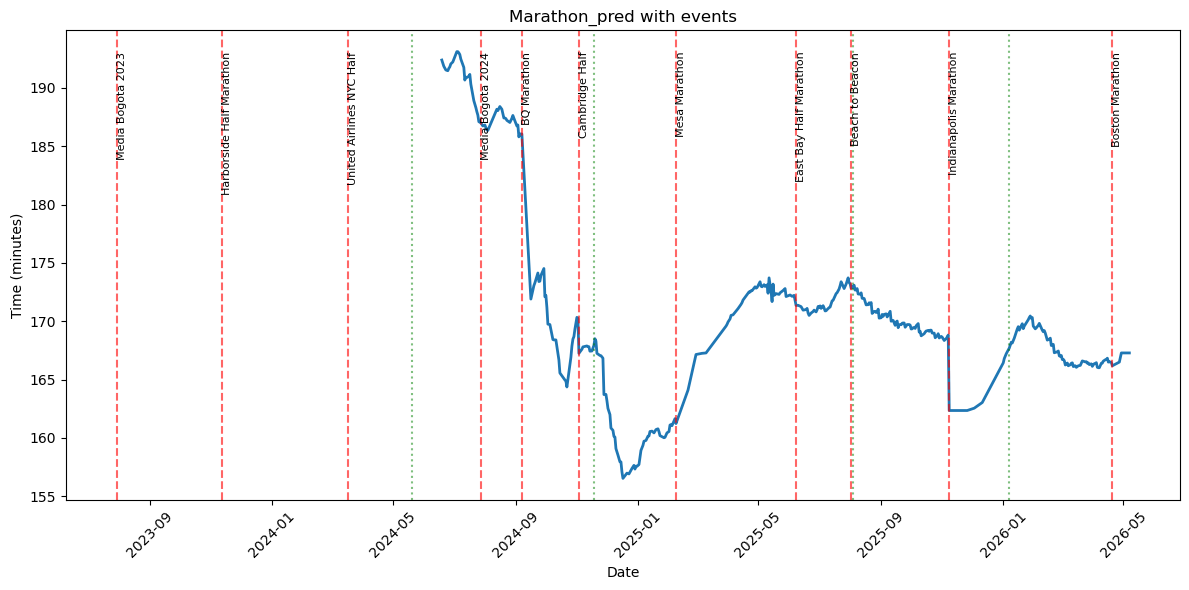

In [4]:
# Load the events table and convert the 'date' column to datetime
events_table = pd.read_csv('/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/events_table.csv')
events_table['date'] = pd.to_datetime(events_table['date'])

# Select races
race_events = events_table[
    events_table["event_type"] == "race"
]

# Select training block starts ()
block_events = events_table[
    events_table["event_type"] == "training_block_start"
    ]

# Plot predictions with race and block start markers
for prediction in predictions_type:
    plot_line_with_events(
        events_table,
        daily_master_table,
        prediction,
        title=f'{prediction} with events'
    )

### Matching Predictions to Race Type

Because Garmin generates predictions for multiple race distances simultaneously (5K, 10K, Half Marathon, and Marathon), each race must be matched to its corresponding prediction type before evaluation.

For example:
- marathon races are evaluated against `Marathon_pred`,
- half marathons against `Half_pred`,
- and so on.

This creates a unified evaluation framework that allows Garmin prediction accuracy to be compared across race events.

When defining `prediction_date` I chose the prediction of the date prior to the race to prevent from any possible data leakage occuring as a result of the race being taken into account when the software makes it's race prediction.

In [5]:
# Prediction date = day before race
race_events["prediction_date"] = race_events["date"] - pd.Timedelta(days=1)

# Select prediction columns
prediction_cols = [
    "date",
    "5K_pred",
    "10K_pred",
    "Half_pred",
    "Marathon_pred"
]

daily_sorted = daily_master_table.sort_values("date")
race_sorted = race_events.sort_values("prediction_date")

race_prediction_eval_df = merge_dataframes_asof(
    left_df=race_sorted,
    right_df=daily_sorted[prediction_cols],
    left_on="prediction_date",
    right_on="date",
    direction="backward"
)

race_prediction_eval_df = race_prediction_eval_df.rename(
    columns={"date_x": "race_date", "date_y": "prediction_date_matched"}
)


/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_12664/934245790.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  race_events["prediction_date"] = race_events["date"] - pd.Timedelta(days=1)


### Prediction Error
Now I will compute prediction error of the races by:
    `prediction_error` = `relevant_pred` - `official_time_min`

This metric will allow me to evaluate statistical trends of the predictions.

In [6]:
# Get the relevant prediction for each race
race_prediction_eval_df["relevant_prediction"] = (
    race_prediction_eval_df.apply(
        get_relevant_prediction,
        axis=1
    )
)

# Compute prediction error
race_prediction_eval_df["prediction_error"] = (
    race_prediction_eval_df["relevant_prediction"]
    - race_prediction_eval_df["official_time_min"]
)

# Display statistics about prediction error
race_prediction_eval_df.groupby("race_type")[
    "prediction_error"
].agg(["mean", "std", "count"])

,mean,std,count
race_type,,,
10k,-0.117000,NaN,1
half,-1.855667,1.683857,3
marathon,-0.573992,6.295077,4


The statistical features of prediction error by `race_type` is incredibly informative.
- I run more longer distance races (half and full marathons)
- As the distance of the race increases, the standard deviation of the error also increases.
- On average it appears that Garmin's predictions are usually faster than my actual times
    - This is more apparent for the half marathon distance. 


### Official Time vs. Garmin Prediction
The following visualization illustrates where my official race times compare to Garmin's prediction. Each race is represented as a circle. If the circle lies above the dotted line (perfect prediction) then my time was faster than the prediction, conversely, if the circle lies below the dotted line my official time was slower. 

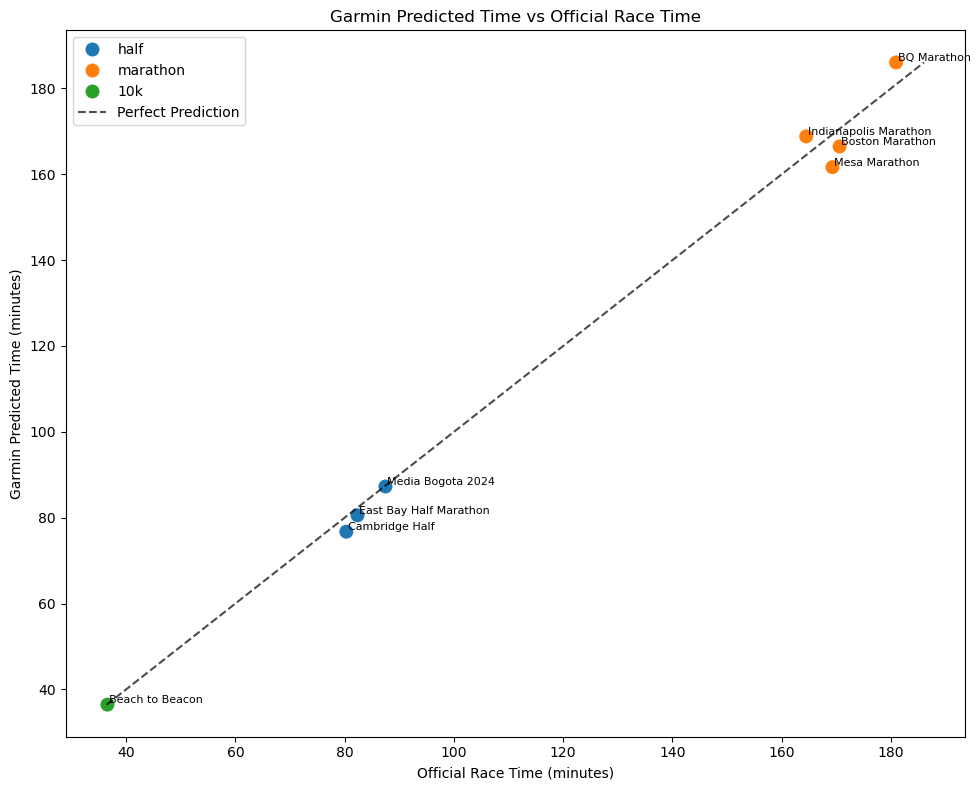

In [7]:
# Plot official time vs predicted time
plt.figure(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=race_prediction_eval_df,
    x="official_time_min",
    y="relevant_prediction",
    hue="race_type",
    s=120
)

# Perfect prediction reference line
min_val = min(
    race_prediction_eval_df["official_time_min"].min(),
    race_prediction_eval_df["relevant_prediction"].min()
)

max_val = max(
    race_prediction_eval_df["official_time_min"].max(),
    race_prediction_eval_df["relevant_prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black",
    alpha=0.7,
    label="Perfect Prediction"
)

# Annotate race names
for _, row in race_prediction_eval_df.iterrows():

    if pd.notna(row["relevant_prediction"]):

        plt.text(
            row["official_time_min"] + 0.3,
            row["relevant_prediction"] + 0.3,
            row["label"],
            fontsize=8
        )

plt.title("Garmin Predicted Time vs Official Race Time")
plt.xlabel("Official Race Time (minutes)")
plt.ylabel("Garmin Predicted Time (minutes)")
plt.legend()
plt.tight_layout()
plt.show()

As can be observed above the official races I have ran can be placed into three categories:
- 10k
- Half Marathon
- Marathon
Unsurprisingly, most of the official races are marathons since that is the distance I've been training and racing for the past few years.

As mentioned previously, as the distance of the race increases, so does the standard deviation of the predictione error, which reflects that longer distances are harder to predict since there are more variables that come into play. 

In addition, I observe that my Garmin consistently predicts my half marathon time to be faster than what I actually run. On the other hand, marathon predictions are a bit more volatile with half of the samples being faster and the other half being slower. 

### Error by Race Type

I willl now proivde a visualization of error by race types, this once again shows how the marathon has the most volatile prediction error.

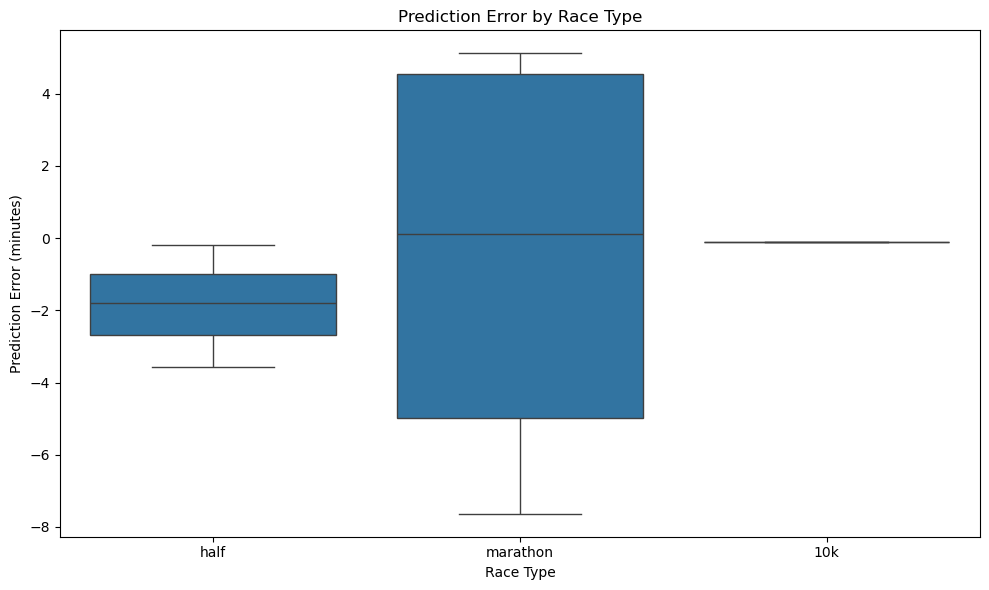

In [8]:
# Compute error by race type and plot boxplot of prediction error
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=race_prediction_eval_df, x="race_type", y="prediction_error")
plt.title("Prediction Error by Race Type")
plt.xlabel("Race Type")
plt.ylabel("Prediction Error (minutes)")
plt.tight_layout()
plt.show()

### Optimisim / Conservatism analysis
In order to compare the prediction of races I will categorize each prediction as being either optimistic or conservative. 
A race prediction is considered optimistic if `prediction_error` < 0, on the other hand, a race prediction is considered conservative if `prediction_error` > 0. There is no sample where `prediction_error` matches actual time, but this would be categorized as a neutral sample. 

In [9]:
# optimism/conservatism analysis
race_prediction_eval_df["error_category"] = race_prediction_eval_df["prediction_error"].apply(
    lambda x: "optimistic" if x < 0 else ("conservative" if x > 0 else "neutral"))

# Manually set inidianapolis marathon prediction date to be two days before the race, in order to address a bug where leakeage occured.
race_prediction_eval_df["prediction_date_matched"][9] = pd.to_datetime("2025-11-01")
race_prediction_eval_df["prediction_date"][9] = pd.to_datetime("2025-11-01")

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_12664/411279466.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  race_prediction_eval_df["prediction_date_matched"][9] = pd.to_datetime("2025-11-01")
/var/folders/5p/042l2mfn5lg_l

### Volatility Analysis

In order to analyze the volatility in the data, I compute the rolling standard deviation of the predictions, in the 7, 15, and 30 days leading up to each race. These derived features will become essential for future analysis.

In [10]:
# Volatility analysis: compute rolling std of predictions in the 7, 15, and 30 days leading up to each race
time_windows = [7, 15, 30]

for time in time_windows:
    daily_master_table[f"rolling_std_{time}_5Kd"] = (
        daily_master_table["5K_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_10Kd"] = (
        daily_master_table["10K_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_Halfd"] = (
        daily_master_table["Half_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_Marathond"] = (
        daily_master_table["Marathon_pred"].rolling(window=time).std()
    )

# A lot of these dates are NaN because of the rolling window, but we can still merge these features into the race_prediction_eval_df for analysis
rolling_cols = [col for col in daily_master_table.columns if "rolling_std" in col]
daily_sorted = daily_master_table.sort_values("date")
race_prediction_eval_df = pd.merge_asof(
    race_prediction_eval_df,
    daily_sorted[["date"] + rolling_cols],
    left_on="prediction_date_matched",
    right_on="date",
    direction="backward"
)


I am interested in comparing the rolling standard deviation of the predictions between predictions categorized as optimistic and conservative. For this I will onlybe obeserving predictions for the half marathon and marathon distances since 5k and 10k predictions have a lot of missing values. 

### Marathon Blocks

For the remainder of this analysis, I will be focusing solely on my marathon races data for the following two reasons:
1. This is my main distance
2. There exists data for 4 main marathon blocks

I will create new dataframes for each marathon block which is roughly aroung 8-12 weeks of training. 


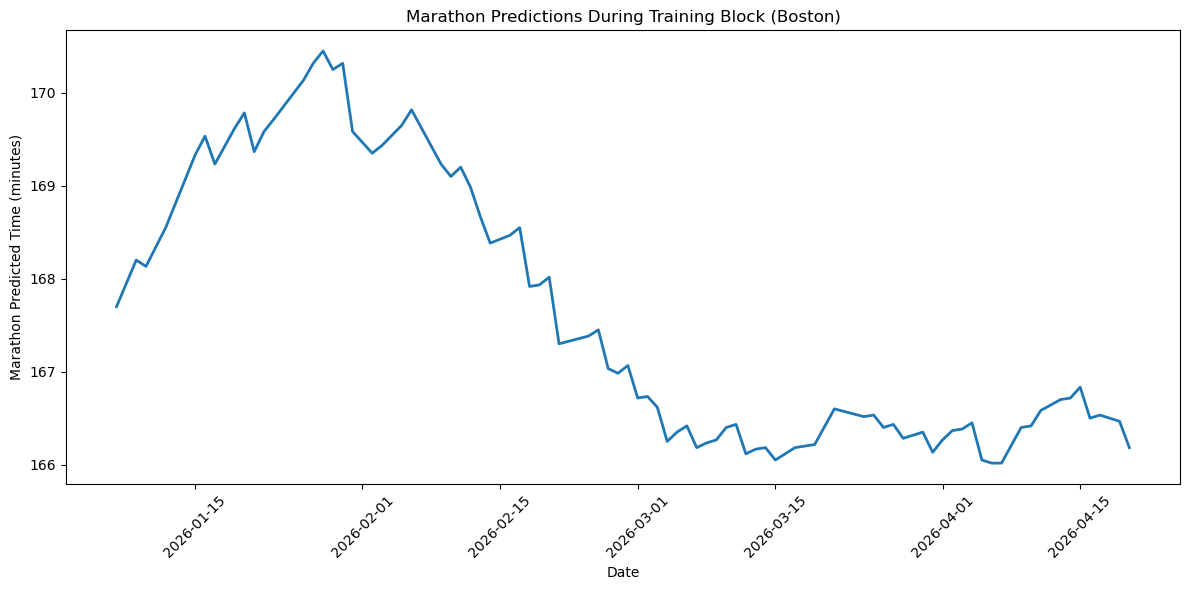

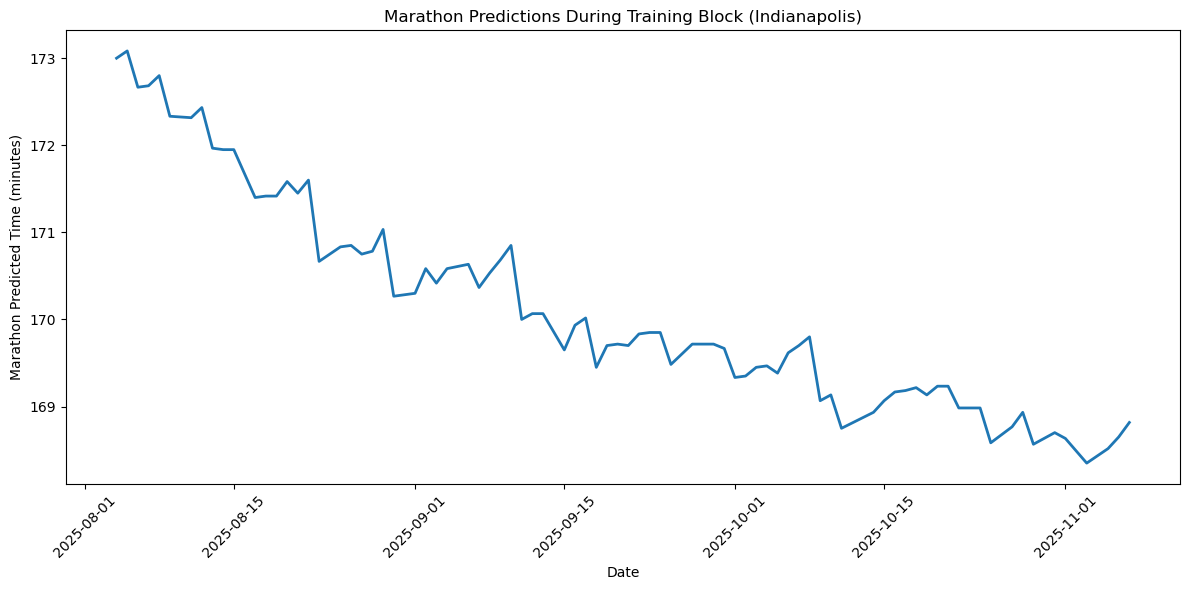

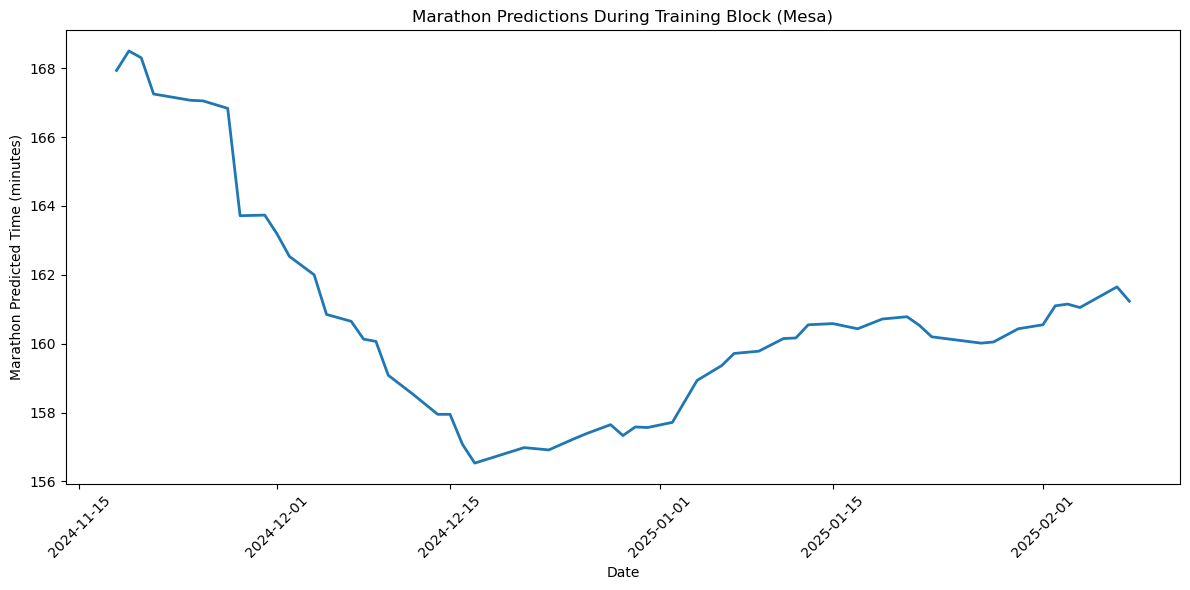

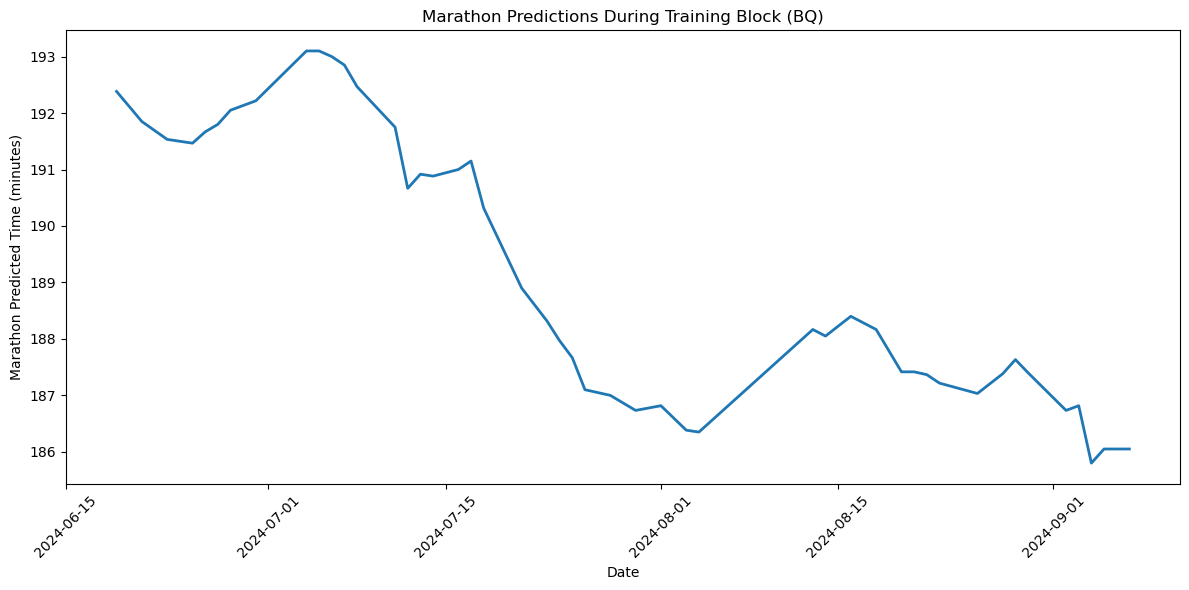

In [11]:
# There exist 4 marathon blocks in the events table
# Create a new dataframe for each marathon block using the dates in the table, manually select the dates
boston_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("2026-01-07")) &
    (daily_master_table["date"] <= pd.to_datetime("2026-04-20"))
]

indianapolis_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("8/4/25")) &
    (daily_master_table["date"] <= pd.to_datetime("11/7/25"))
]

mesa_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("11/18/24")) &
    (daily_master_table["date"] <= pd.to_datetime("2/8/25"))
]

bq_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("2024-06-19")) &
    (daily_master_table["date"] <= pd.to_datetime("9/7/24"))
]

marathon_blocks = {"Boston" : boston_block_daily, 
                   "Indianapolis" : indianapolis_block_daily, 
                   "Mesa" : mesa_block_daily, 
                   "BQ" : bq_block_daily}

# Plot marathon predictions over time for each marathon block
for block in marathon_blocks:
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=marathon_blocks[block],
        x='date',
        y='Marathon_pred',
        linewidth=2
    )
    plt.title(f'Marathon Predictions During Training Block ({block})')
    plt.xlabel('Date')
    plt.ylabel('Marathon Predicted Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


The four plots above begin to reveal some very fascinating information about how Garmin's race prediction actually looks, mainly that the prediction evolution for each block looks very different.
- As expected the prediction time from the beginning of the block to the end decreases for all four blocks.
- I observe hump structures in all plots, however these all vary in size and in when they occur during the block.

In [12]:
# Add information from the race_prediction_eval_df into the marathon block dataframes for further analysis
boston_block_daily = pd.merge_asof(
    boston_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
indianapolis_block_daily = pd.merge_asof(
    indianapolis_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
mesa_block_daily = pd.merge_asof(
    mesa_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
bq_block_daily = pd.merge_asof(
    bq_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)

# Clean up the marathon block dataframes by dropping columns that were duplicated during the merge and are not relevant
columns_to_drop = [
    "5K_pred_y",
    "10K_pred_y",
    "Half_pred_y",
    "Marathon_pred_y",
    "rolling_std_7_5Kd_y",
    "rolling_std_15_5Kd_y",
    "rolling_std_30_5Kd_y",
    "rolling_std_7_10Kd_y",
    "rolling_std_15_10Kd_y",
    "rolling_std_30_10Kd_y",
    "rolling_std_7_Halfd_y",
    "rolling_std_15_Halfd_y",
    "rolling_std_30_Halfd_y",
    "rolling_std_7_Marathond_y",
    "rolling_std_15_Marathond_y",
    "rolling_std_30_Marathond_y",
    "5K_pred_x",
    "10K_pred_x",
    "Half_pred_x",
    "rolling_std_7_5Kd_x",
    "rolling_std_15_5Kd_x",
    "rolling_std_30_5Kd_x",
    "rolling_std_7_10Kd_x",
    "rolling_std_15_10Kd_x",
    "rolling_std_30_10Kd_x",
    "rolling_std_7_Halfd_x",
    "rolling_std_15_Halfd_x",
    "rolling_std_30_Halfd_x",
]

boston_block_daily = boston_block_daily.drop(columns=columns_to_drop)
indianapolis_block_daily = indianapolis_block_daily.drop(columns=columns_to_drop)
mesa_block_daily = mesa_block_daily.drop(columns=columns_to_drop)  
bq_block_daily = bq_block_daily.drop(columns=columns_to_drop)

### Rolling Prediction Volatility Across Marathon Blocks

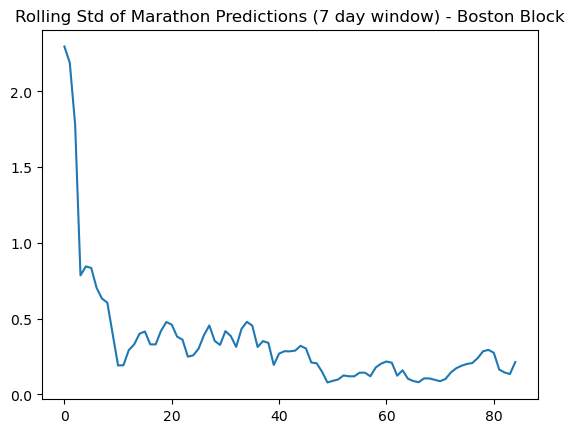

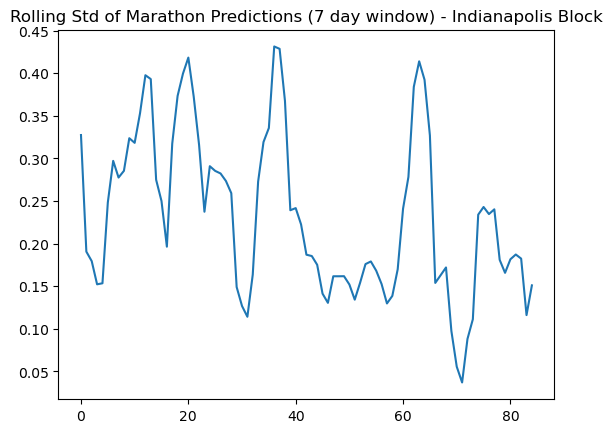

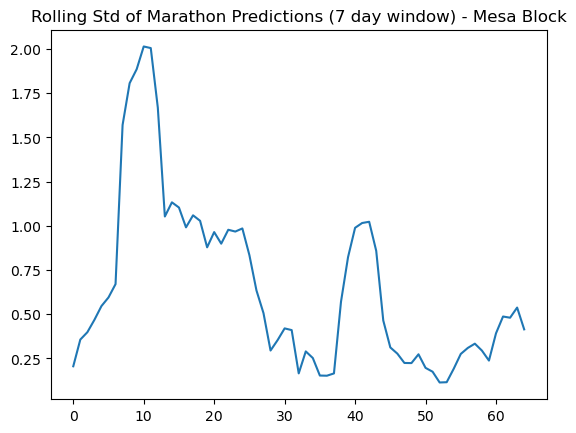

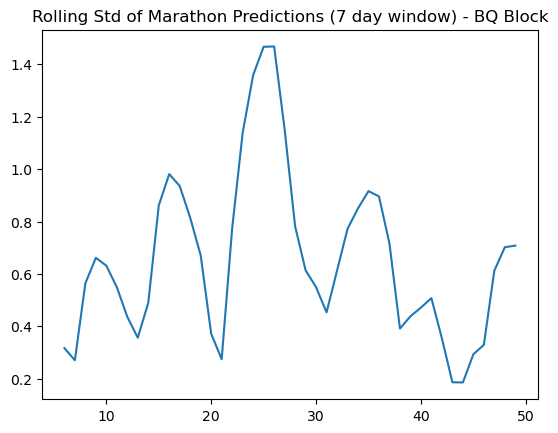

In [13]:
# Determine when predictions start to become more stable (less volatile) using the rolling std features in the marathon blocks
boston_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Boston Block")
plt.show()

indianapolis_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Indianapolis Block")
plt.show()

mesa_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Mesa Block")
plt.show()

bq_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - BQ Block")
plt.show()

The rolling standard deviation plots reveal that Garmin marathon prediction behavior varies substantially across different training blocks. Rather than following a single consistent pattern, each block appears to exhibit its own distinct prediction dynamics.

Several observations stand out immediately:

- The Indianapolis Marathon block appears relatively stable throughout most of the training cycle, with consistently low rolling volatility. Interestingly, this block also resulted in the strongest marathon performance in the dataset.
  
- The Mesa Marathon block shows significantly higher volatility, including multiple abrupt spikes and large fluctuations in predicted marathon fitness. This same block also produced Garmin’s largest optimistic prediction error relative to the official race result.

- The Boston Marathon block demonstrates an initial adaptation period followed by a long phase of remarkably low volatility, suggesting that Garmin’s prediction system may have converged on a stable estimate of fitness late in the cycle.

- The BQ Marathon block displays repeated oscillatory behavior, with several cycles of increasing and decreasing volatility. This may indicate that Garmin repeatedly reevaluated fitness status throughout the build.

These results suggest that the *dynamics* of Garmin race predictions may be just as important as the final predicted value itself. In particular, prediction stability and volatility may provide insight into:
- training consistency,
- physiological adaptation,
- model confidence,
- or uncertainty in estimated marathon fitness.

At this stage, no definitive conclusions are being made. However, the differences between marathon blocks suggest that prediction volatility may be a meaningful signal worth investigating further.

In [14]:
boston_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/boston_block_daily_v1.parquet',
    index=False
)
indianapolis_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/indianapolis_block_daily_v1.parquet',
    index=False
)
mesa_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/mesa_block_daily_v1.parquet',
    index=False
)
bq_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/bq_block_daily_v1.parquet',
    index=False
)

### Block Summary Table

In [15]:
block_dict = {
    "BQ Marathon": bq_block_daily,
    "Mesa Marathon": mesa_block_daily,
    "Indianapolis Marathon": indianapolis_block_daily,
    "Boston Marathon": boston_block_daily
}

summary_rows = []

for block_name, df in block_dict.items():

    df = df.sort_values("date").reset_index(drop=True)

    # -----------------------------
    # Race row from evaluation df
    # -----------------------------
    race_row = race_prediction_eval_df[
        race_prediction_eval_df["label"].str.contains(
            block_name.split()[0],
            case=False,
            na=False
        )
    ].iloc[0]

    race_date = race_row["race_date"]
    actual_time = race_row["official_time_min"]
    final_prediction = race_row["relevant_prediction"]

    # -----------------------------
    # Prediction error
    # -----------------------------
    prediction_error = final_prediction - actual_time

    if prediction_error < -2:
        prediction_bias = "optimistic"
    elif prediction_error > 2:
        prediction_bias = "conservative"
    else:
        prediction_bias = "neutral"

    # -----------------------------
    # Volatility metrics
    # -----------------------------
    mean_volatility = df["rolling_std_7_Marathond_x"].mean()
    max_volatility = df["rolling_std_7_Marathond_x"].max()

    # -----------------------------
    # Stability logic
    # Define stable as:
    # within ±2 min of final prediction
    # -----------------------------
    tolerance = 2

    stable_mask = (
        (df["Marathon_pred_x"] - final_prediction)
        .abs()
        <= tolerance
    )

    stable_date = pd.NaT

    for i in range(len(df)):
        remaining = stable_mask.iloc[i:]

        if remaining.all():
            stable_date = df.iloc[i]["date"]
            break

    if pd.notnull(stable_date):
        days_stable_before_race = (
            pd.to_datetime(race_date) - stable_date
        ).days
    else:
        days_stable_before_race = np.nan

    # -----------------------------
    # Weekly mileage
    # -----------------------------
    weekly_mileage = (
        df
        .set_index("date")["total_distance_miles"]
        .resample("W")
        .sum()
    )

    peak_weekly_mileage = weekly_mileage.max()
    avg_weekly_mileage = weekly_mileage.mean()

    # -----------------------------
    # Last 14 day avg prediction
    # -----------------------------
    last_14_day_avg_prediction = (
        df.tail(14)["Marathon_pred_x"].mean()
    )

    # -----------------------------
    # Prediction drift
    # -----------------------------
    prediction_drift = (
        final_prediction
        - df["Marathon_pred_x"].iloc[0]
    )

    # -----------------------------
    # Avg training load
    # -----------------------------
    avg_training_load = (
        df["total_training_load"].mean()
    )

    # -----------------------------
    # Avg readiness
    # -----------------------------
    avg_readiness = (
        df["readiness_score_mean"].mean()
    )

    # -----------------------------
    # VO2 drift
    # -----------------------------
    vo2_drift = (
        df["vo2MaxValue"].iloc[-1]
        - df["vo2MaxValue"].iloc[0]
    )

    # -----------------------------
    # Avg HRV
    # -----------------------------
    avg_hrv = (
        df["hrv_weekly_avg_clean"].mean()
    )

    # -----------------------------
    # Append row
    # -----------------------------
    summary_rows.append({
        "block_name": block_name,
        "race_date": race_date,
        "actual_time": actual_time,
        "final_prediction": final_prediction,
        "prediction_error": prediction_error,
        "prediction_bias": prediction_bias,
        "mean_volatility": mean_volatility,
        "max_volatility": max_volatility,
        "stable_date": stable_date,
        "days_stable_before_race": days_stable_before_race,
        "peak_weekly_mileage": peak_weekly_mileage,
        "avg_weekly_mileage": avg_weekly_mileage,
        "last_14_day_avg_prediction": last_14_day_avg_prediction,
        "prediction_drift": prediction_drift,
        "avg_training_load": avg_training_load,
        "avg_readiness": avg_readiness,
        "vo2_drift": vo2_drift,
        "avg_hrv": avg_hrv
    })

summary_table = pd.DataFrame(summary_rows)

table = tabulate(
    summary_table,
    headers="keys",
    tablefmt="pretty",
    showindex=False
)
print(table)

+-----------------------+---------------------+-------------+--------------------+--------------------+-----------------+--------------------+---------------------+---------------------+-------------------------+---------------------+--------------------+----------------------------+--------------------+--------------------+-------------------+-----------+--------------------+
|      block_name       |      race_date      | actual_time |  final_prediction  |  prediction_error  | prediction_bias |  mean_volatility   |   max_volatility    |     stable_date     | days_stable_before_race | peak_weekly_mileage | avg_weekly_mileage | last_14_day_avg_prediction |  prediction_drift  | avg_training_load  |   avg_readiness   | vo2_drift |      avg_hrv       |
+-----------------------+---------------------+-------------+--------------------+--------------------+-----------------+--------------------+---------------------+---------------------+-------------------------+---------------------+------

### Preliminary Block-Level Findings

Several meaningful differences emerge when comparing marathon training blocks at an aggregate level.

The Indianapolis Marathon block exhibited the lowest prediction volatility by a substantial margin, while also corresponding to the strongest marathon performance and highest sustained mileage in the dataset. In contrast, the Mesa Marathon block displayed significantly higher volatility and Garmin’s largest optimistic prediction error.

Interestingly, both the Boston and Indianapolis blocks stabilized far earlier than the BQ block, suggesting that Garmin’s prediction system may become more confident during mature or highly consistent training cycles. (Also more running experience)

Prediction bias was not uniform across races. Garmin alternated between optimistic and conservative behavior depending on the block, suggesting that prediction dynamics may depend heavily on training structure, fatigue state, or adaptation patterns rather than a simple systematic bias.

These findings remain exploratory, but they suggest that prediction volatility and stabilization behavior may provide meaningful signals beyond the final race prediction itself.

Limitations Section